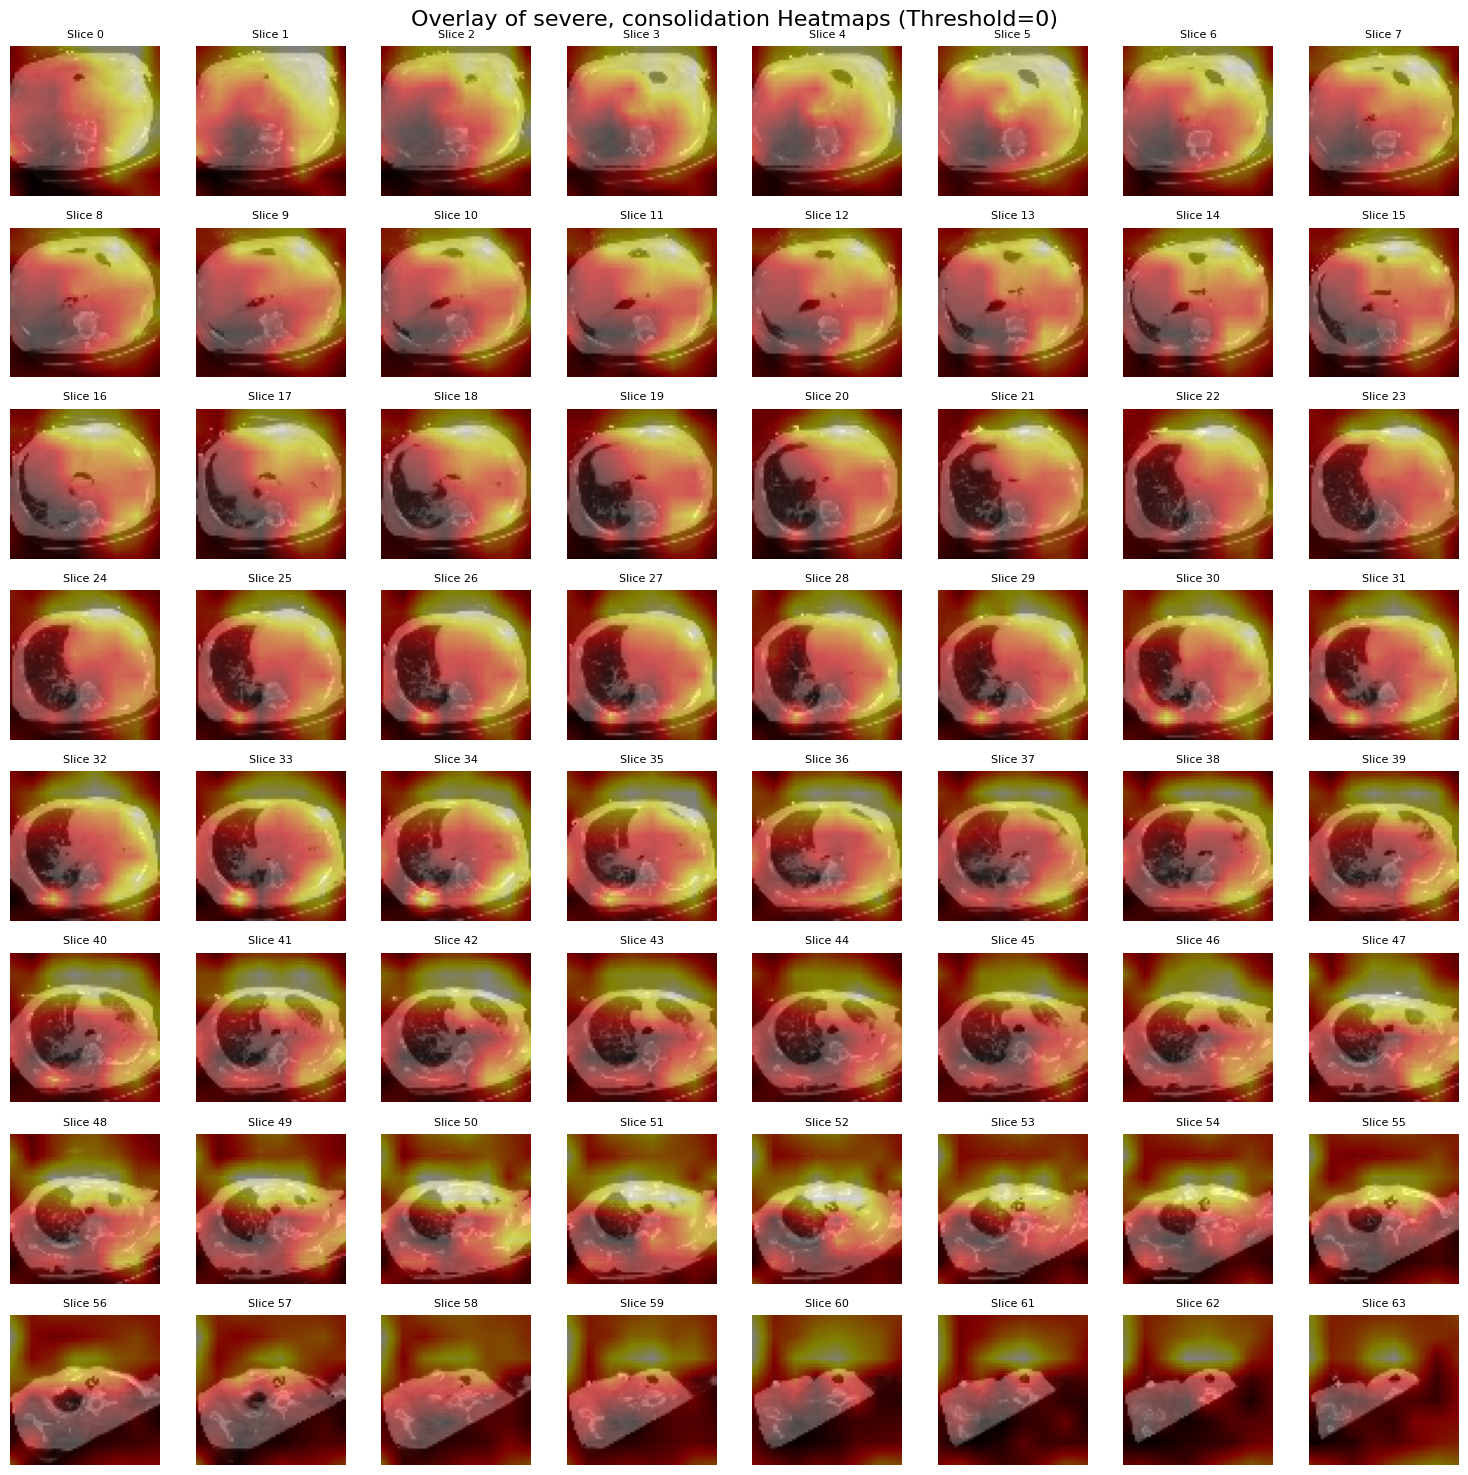

In [ ]:
# main statiic scirpt to overlay heatmaps on CT scans

import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import zoom

ct_scan_path = "/media/volume/gen-ai-volume/MedSyn/results/img_64_standard/111222000/111222000_sample_0.npy"
heatmaps_folder = "/media/volume/gen-ai-volume/MedSyn/results/saliency_maps/111222000/"

# === Token–Filename Mapping ===
heatmap_files = {
    "left":    "111222000_sample_0_token_1_left_heatmaps.npy",
    "severe":  "111222000_sample_0_token_2_severe_heatmaps.npy",
    "consolidation": "111222000_sample_0_token_3_consolidation_heatmaps.npy",
}

ct_volume = np.load(ct_scan_path) 
ct_slices = ct_volume[0, 0, :, :, :] 

def resize_heatmap(heatmap, target_shape=(64, 64, 64)):
    zoom_factors = (
        target_shape[0] / heatmap.shape[0],  # Depth
        target_shape[1] / heatmap.shape[1],  # Height
        target_shape[2] / heatmap.shape[2],  # Width
    )
    return zoom(heatmap, zoom_factors, order=1)  



# selected_tokens = ["left"]
selected_tokens = ["severe", "consolidation"]
# selected_tokens = ["right"]
# selected_tokens = ["right", "pleural", "effusion"]

# selected_tokens = ["severe", "left", "pleural_1", "effusion_1"]
#selected_tokens = ["right"]   
heatmap_threshold = 0.05
selected_tokens = list(set(selected_tokens))

heatmap_stack = []
valid_pixel_counts = np.zeros((64, 64, 64))  # Count valid pixels to avoid spreading noise

for token in selected_tokens:
    heatmap_path = os.path.join(heatmaps_folder, heatmap_files[token])

    if os.path.exists(heatmap_path):
        heatmap_data = np.load(heatmap_path)  # Shape: (64, 8, 8)
        resized_heatmap = resize_heatmap(heatmap_data, target_shape=(64, 64, 64))
        
        # Apply threshold to each heatmap separately before averaging
        thresholded_heatmap = np.where(resized_heatmap >= heatmap_threshold, resized_heatmap, 0)

        # Keep track of the number of valid pixels per voxel
        valid_pixel_counts += (thresholded_heatmap > 0).astype(np.float32)

        heatmap_stack.append(thresholded_heatmap)
    else:
        print(f"Heatmap file '{heatmap_path}' not found.")

if len(heatmap_stack) == 0:
    raise ValueError("No valid heatmaps selected.")

sum_heatmap = np.sum(np.stack(heatmap_stack, axis=0), axis=0)

avg_heatmap = np.where(valid_pixel_counts > 0, sum_heatmap / valid_pixel_counts, 0)

def overlay_binary_heatmap_on_ct(ct_scan, heatmap, title):
    fig, axes = plt.subplots(8, 8, figsize=(15, 15))
    axes = axes.flatten()

    for i in range(64):
        ct_slice_norm = (ct_scan[i, :, :] - np.min(ct_scan[i, :, :])) / (
            np.max(ct_scan[i, :, :]) - np.min(ct_scan[i, :, :]) + 1e-8
        )
        ct_slice_norm = np.flipud((ct_slice_norm))  

        heatmap_slice = heatmap[i, :, :] 
        heatmap_slice = np.flipud(heatmap_slice) 

        axes[i].imshow(ct_slice_norm, cmap="gray")  
        if np.any(heatmap_slice > 0):  
            heatmap_masked_slice = np.ma.masked_where(heatmap_slice <= 0, heatmap_slice)
            axes[i].imshow(heatmap_masked_slice, cmap="hot", alpha=0.5, interpolation="nearest")  

        axes[i].set_title(f"Slice {i}", fontsize=8)
        axes[i].axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

overlay_binary_heatmap_on_ct(
    ct_slices,
    avg_heatmap,
    title=f"Overlay of {', '.join(selected_tokens)} Heatmaps (Threshold={heatmap_threshold})"
)


In [13]:
# GFI gerneration of video
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import cv2
from scipy.ndimage import zoom

# Define paths
ct_scan_path = "/media/volume/gen-ai-volume/MedSyn/results/img_64_standard/111222444/111222444_sample_0.npy"
heatmaps_folder = "/media/volume/gen-ai-volume/MedSyn/results/saliency_maps/111222444/"

# Heatmap files
heatmap_files = {
    "mild": "111222444_sample_0_token_1_mild_heatmaps.npy",
    "right": "111222444_sample_0_token_2_right_heatmaps.npy",
    "pleural_1": "111222444_sample_0_token_3_pleural_heatmaps.npy",
    "effusion_1": "111222444_sample_0_token_4_effusion_heatmaps.npy",
    "severe": "111222444_sample_0_token_6_severe_heatmaps.npy",
    "left": "111222444_sample_0_token_7_left_heatmaps.npy",
    "pleural_2": "111222444_sample_0_token_8_pleural_heatmaps.npy",
    "effusion_2": "111222444_sample_0_token_9_effusion_heatmaps.npy",
}

# Load CT scan
ct_volume = np.load(ct_scan_path)
ct_slices = ct_volume[0, 0, :, :, :]  # Shape: (64, 64, 64)

# Resize function
def resize_heatmap(heatmap, target_shape=(64, 64, 64)):
    zoom_factors = (
        target_shape[0] / heatmap.shape[0],  # Depth
        target_shape[1] / heatmap.shape[1],  # Height
        target_shape[2] / heatmap.shape[2],  # Width
    )
    return zoom(heatmap, zoom_factors, order=1)

# Select tokens
selected_tokens = ["severe", "left", "pleural_1", "effusion_1"]
heatmap_threshold = 0.075  
selected_tokens = list(set(selected_tokens))

# Process heatmaps
heatmap_stack = []
valid_pixel_counts = np.zeros((64, 64, 64))

for token in selected_tokens:
    heatmap_path = os.path.join(heatmaps_folder, heatmap_files[token])
    if os.path.exists(heatmap_path):
        heatmap_data = np.load(heatmap_path)
        resized_heatmap = resize_heatmap(heatmap_data, target_shape=(64, 64, 64))
        thresholded_heatmap = np.where(resized_heatmap >= heatmap_threshold, resized_heatmap, 0)
        valid_pixel_counts += (thresholded_heatmap > 0).astype(np.float32)
        heatmap_stack.append(thresholded_heatmap)
    else:
        print(f"Heatmap file '{heatmap_path}' not found.")

if len(heatmap_stack) == 0:
    raise ValueError("No valid heatmaps selected.")

sum_heatmap = np.sum(np.stack(heatmap_stack, axis=0), axis=0)
avg_heatmap = np.where(valid_pixel_counts > 0, sum_heatmap / valid_pixel_counts, 0)

# Video settings
video_filename = "ct_heatmap_overlay.mp4"
fps = 5  # Frames per second
frame_size = (512, 512)  # Resize for better visualization

# Initialize video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_out = cv2.VideoWriter(video_filename, fourcc, fps, frame_size)

# Generate video frames
for i in range(64):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.axis("off")

    # Normalize CT slice
    ct_slice_norm = (ct_slices[i, :, :] - np.min(ct_slices[i, :, :])) / (
        np.max(ct_slices[i, :, :]) - np.min(ct_slices[i, :, :]) + 1e-8
    )

    # Plot CT scan slice
    ax.imshow(ct_slice_norm, cmap="gray")

    # Plot heatmap overlay
    heatmap_slice = avg_heatmap[i, :, :]
    if np.any(heatmap_slice > 0):
        heatmap_masked_slice = np.ma.masked_where(heatmap_slice <= 0, heatmap_slice)
        ax.imshow(heatmap_masked_slice, cmap="Reds", alpha=0.5, interpolation="nearest")

    ax.set_title(f"Slice {i}")

    # Save frame as image
    plt.tight_layout()
    plt.savefig("temp_frame.png", bbox_inches="tight", pad_inches=0)
    plt.close(fig)

    # Read frame and resize
    frame = cv2.imread("temp_frame.png")
    frame = cv2.resize(frame, frame_size)

    # Write frame to video
    video_out.write(frame)

# Release video writer and clean up
video_out.release()
os.remove("temp_frame.png")

print(f"Video saved as {video_filename}")


FileNotFoundError: [Errno 2] No such file or directory: '/media/volume/gen-ai-volume/MedSyn/results/img_64_standard/111222444/111222444_sample_0.npy'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from scipy.ndimage import zoom

# Define paths
ct_scan_path = "/media/volume/gen-ai-volume/MedSyn/results/img_64_standard/111222444/111222444_sample_0.npy"
heatmaps_folder = "/media/volume/gen-ai-volume/MedSyn/results/saliency_maps/111222444/"

# Heatmap files
heatmap_files = {
    "mild": "111222444_sample_0_token_1_mild_heatmaps.npy",
    "right": "111222444_sample_0_token_2_right_heatmaps.npy",
    "pleural_1": "111222444_sample_0_token_3_pleural_heatmaps.npy",
    "effusion_1": "111222444_sample_0_token_4_effusion_heatmaps.npy",
    "severe": "111222444_sample_0_token_6_severe_heatmaps.npy",
    "left": "111222444_sample_0_token_7_left_heatmaps.npy",
    "pleural_2": "111222444_sample_0_token_8_pleural_heatmaps.npy",
    "effusion_2": "111222444_sample_0_token_9_effusion_heatmaps.npy",
}

# Load CT scan
ct_volume = np.load(ct_scan_path)
ct_slices = ct_volume[0, 0, :, :, :]  # Shape: (64, 64, 64)

# Resize function
def resize_heatmap(heatmap, target_shape=(64, 64, 64)):
    zoom_factors = (
        target_shape[0] / heatmap.shape[0],  # Depth
        target_shape[1] / heatmap.shape[1],  # Height
        target_shape[2] / heatmap.shape[2],  # Width
    )
    return zoom(heatmap, zoom_factors, order=1)

# Select tokens
selected_tokens = ["right"]
# selected_tokens = ["severe", "left", "pleural_1", "effusion_1"]
heatmap_threshold = 0.075  
selected_tokens = list(set(selected_tokens))

# Process heatmaps
heatmap_stack = []
valid_pixel_counts = np.zeros((64, 64, 64))

for token in selected_tokens:
    heatmap_path = os.path.join(heatmaps_folder, heatmap_files[token])
    if os.path.exists(heatmap_path):
        heatmap_data = np.load(heatmap_path)
        resized_heatmap = resize_heatmap(heatmap_data, target_shape=(64, 64, 64))
        thresholded_heatmap = np.where(resized_heatmap >= heatmap_threshold, resized_heatmap, 0)
        valid_pixel_counts += (thresholded_heatmap > 0).astype(np.float32)
        heatmap_stack.append(thresholded_heatmap)
    else:
        print(f"Heatmap file '{heatmap_path}' not found.")

if len(heatmap_stack) == 0:
    raise ValueError("No valid heatmaps selected.")

sum_heatmap = np.sum(np.stack(heatmap_stack, axis=0), axis=0)
avg_heatmap = np.where(valid_pixel_counts > 0, sum_heatmap / valid_pixel_counts, 0)

# Video settings
video_filename = "ct_heatmap_overlay_256_Red_right.mp4"
fps = 5  # Frames per second
output_resolution = (256, 256)  # Bilinear interpolation to 256x256

# Initialize video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_out = cv2.VideoWriter(video_filename, fourcc, fps, output_resolution)

# Generate video frames
for i in range(64):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.axis("off")

    # Normalize CT slice
    ct_slice_norm = (ct_slices[i, :, :] - np.min(ct_slices[i, :, :])) / (
        np.max(ct_slices[i, :, :]) - np.min(ct_slices[i, :, :]) + 1e-8
    )

    # Plot CT scan slice
    ax.imshow(ct_slice_norm, cmap="gray")

    # Plot heatmap overlay
    heatmap_slice = avg_heatmap[i, :, :]
    if np.any(heatmap_slice > 0):
        heatmap_masked_slice = np.ma.masked_where(heatmap_slice <= 0, heatmap_slice)
        ax.imshow(heatmap_masked_slice, cmap="Reds", alpha=0.5, interpolation="nearest")

    ax.set_title(f"Slice {i}")

    # Save frame as image
    plt.tight_layout()
    plt.savefig("temp_frame.png", bbox_inches="tight", pad_inches=0)
    plt.close(fig)

    # Read frame and resize using bilinear interpolation
    frame = cv2.imread("temp_frame.png")
    frame = cv2.resize(frame, output_resolution, interpolation=cv2.INTER_LINEAR)

    # Write frame to video
    video_out.write(frame)

# Release video writer and clean up
video_out.release()
os.remove("temp_frame.png")

print(f"Video saved as {video_filename}")


FileNotFoundError: [Errno 2] No such file or directory: '/media/volume/gen-ai-volume/MedSyn/results/img_64_standard/111222444/111222444_sample_0.npy'